# Exploración del Dataset `rel-f1`
## Recolección, Preprocesamiento y Análisis Estructural del Grafo

**Curso:** Graph Machine Learning — Temas Avanzados de IA (1INF61)  
**PUCP — Semestre 2026-1**  
**Entregable 2:** Recolección y Preprocesamiento de Datos

---

### Descripción
Este notebook implementa el pipeline completo de recolección, preprocesamiento y análisis del dataset `rel-f1` de [RelBench](https://github.com/snap-stanford/relbench) — un benchmark de Relational Deep Learning basado en datos históricos de Fórmula 1.

**Estructura del grafo relacional:**
```
circuit
  │
  └──< race >──< results >──< driver
                    │
               constructor
```

**Tarea objetivo:** `driver-circuit-compete` — tarea de **link prediction / recomendación**: dado el historial de un piloto, predecir en qué circuitos competirá durante el próximo año.


---
### ⚙️ Si estás en Google Colab
Ejecuta esta celda primero (instala las librerías que Colab no trae por defecto).  
En un entorno local con `venv` ya configurado, puedes saltarla.

In [103]:
# Descomenta y ejecuta solo en Google Colab
# !pip install -q relbench torch_geometric
# !pip install -q "numpy<2"   # evita el warning de incompatibilidad con torch_frame
print('Celda de setup para Colab (sin efecto en entorno local)')

Celda de setup para Colab (sin efecto en entorno local)


---
## 0 · Imports y verificación del entorno

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import torch
import warnings

from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
%matplotlib inline
print('Imports OK')

Imports OK


In [105]:
import torch
import torch_geometric
import relbench
import importlib.metadata

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
relbench_version = importlib.metadata.version('relbench')

print(f'PyTorch   : {torch.__version__}')
print(f'CUDA      : {torch.cuda.is_available()} | {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"}')
print(f'PyG       : {torch_geometric.__version__}')
print(f'RelBench  : {relbench_version}')
print(f'Device    : {device}')

PyTorch   : 2.3.0+cu121
CUDA      : True | NVIDIA GeForce RTX 4070 SUPER
PyG       : 2.8.0
RelBench  : 2.1.2
Device    : cuda


---
## 1 · Utilidades reutilizadas de Labs 8, 9 y 10

In [106]:
# ── Utilidades de Lab 8 (métricas de grafo, visualización, MAD) ─────────────

def graph_information(G):
    """Estadísticas básicas del grafo (Lab 8)."""
    print(f'  Nodos   : {G.number_of_nodes()}')
    print(f'  Aristas : {G.number_of_edges()}')
    print(f'  Dirigido: {G.is_directed()}')
    print(f'  Ponderado: {nx.is_weighted(G)}')


def compute_mad(Z, mask=None, eps=1e-8):
    """Mean Average Distance coseno entre pares de nodos (Lab 8)."""
    if torch.is_tensor(Z):
        Z = Z.detach().cpu().numpy()
    Zn = Z / np.clip(np.linalg.norm(Z, axis=1, keepdims=True), eps, None)
    D  = 1.0 - np.clip(Zn @ Zn.T, -1.0, 1.0)
    if mask is None:
        mask = np.ones_like(D)
    else:
        mask = mask.copy()
    np.fill_diagonal(mask, 0)
    total = mask.sum()
    return float((D * mask).sum() / total) if total > 0 else 0.0


def plot_embeddings_3d(Z, title='3D Embeddings', colors=None):
    """Scatter 3D de embeddings Z ∈ R^{n×3} (Lab 8)."""
    if torch.is_tensor(Z):
        Z = Z.detach().cpu().numpy()
    assert Z.shape[1] == 3, 'Se necesitan exactamente 3 dimensiones'
    fig = plt.figure(figsize=(9, 7))
    ax  = fig.add_subplot(projection='3d')
    kw  = dict(s=60, cmap='gist_rainbow')
    if colors is not None:
        kw['c'] = colors
    ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], **kw)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# ── Utilidades de Lab 9 (visualización de grafos) ───────────────────────────

def draw_kkl(nx_G, label_map, node_color, pos=None, title='', **kwargs):
    """Spring layout ajustado al tamaño del grafo (Lab 9)."""
    fig, ax = plt.subplots(figsize=(12, 10))
    if pos is None:
        pos = nx.spring_layout(nx_G, k=5 / np.sqrt(nx_G.number_of_nodes()), seed=42)
    nx.draw(nx_G, pos, with_labels=label_map is not None,
            labels=label_map, node_color=node_color, ax=ax, **kwargs)
    if title:
        ax.set_title(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def accuracy(pred_y, y):
    """Porcentaje de predicciones correctas (Lab 9)."""
    return (pred_y == y).sum() / len(y)


# ── Paleta de colores por tipo de nodo ──────────────────────────────────────
NODE_COLORS = {
    'driver'      : '#4C72B0',  # azul
    'race'        : '#DD8452',  # naranja
    'constructor' : '#55A868',  # verde
    'circuit'     : '#C44E52',  # rojo
}

print('Utilidades cargadas ✓')

Utilidades cargadas ✓


---
## 2 · Recolección de datos — `rel-f1`

**Fuente:** RelBench (Stanford SNAP) — https://relbench.stanford.edu  
**Dataset:** `rel-f1` — snapshot histórico de Fórmula 1 (carreras desde 1950 hasta la fecha de corte del snapshot, nov. 2009)  
**Descarga:** automática vía API de RelBench; se cachea localmente tras la primera descarga (~700 KB).


In [107]:
from relbench.datasets import get_dataset
from relbench.tasks import get_task, get_task_names

print('Cargando rel-f1...')
dataset = get_dataset('rel-f1', download=True)
db      = dataset.get_db()

print(f'\n✓ Dataset cargado')
print(f'  Tablas         : {list(db.table_dict.keys())}')
print(f'  Val timestamp  : {dataset.val_timestamp}')
print(f'  Test timestamp : {dataset.test_timestamp}')
print(f'\nTareas disponibles:')
for t in get_task_names('rel-f1'):
    print(f'  - {t}')

Cargando rel-f1...

✓ Dataset cargado
  Tablas         : ['circuits', 'constructors', 'constructor_results', 'constructor_standings', 'drivers', 'qualifying', 'races', 'results', 'standings']
  Val timestamp  : 2005-01-01 00:00:00
  Test timestamp : 2010-01-01 00:00:00

Tareas disponibles:
  - driver-position
  - driver-dnf
  - driver-top3
  - driver-circuit-compete
  - results-position
  - qualifying-position


---
## 3 · Exploración de tablas

El dataset contiene **9 tablas** que conforman el esquema relacional de F1.

In [108]:
# Resumen del esquema relacional
print('=' * 65)
for name, table in db.table_dict.items():
    df = table.df
    print(f'\n📋 {name.upper()} ({len(df):,} filas)')
    print(f'   Columnas    : {list(df.columns)}')
    print(f'   Primary key : {table.pkey_col}')
    print(f'   Foreign keys: {table.fkey_col_to_pkey_table}')
    if table.time_col:
        print(f'   Time col    : {table.time_col}')
print('=' * 65)


📋 CIRCUITS (77 filas)
   Columnas    : ['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt']
   Primary key : circuitId
   Foreign keys: {}

📋 CONSTRUCTORS (211 filas)
   Columnas    : ['constructorId', 'constructorRef', 'name', 'nationality']
   Primary key : constructorId
   Foreign keys: {}

📋 CONSTRUCTOR_RESULTS (9,408 filas)
   Columnas    : ['constructorResultsId', 'raceId', 'constructorId', 'points', 'date']
   Primary key : constructorResultsId
   Foreign keys: {'raceId': 'races', 'constructorId': 'constructors'}
   Time col    : date

📋 CONSTRUCTOR_STANDINGS (10,170 filas)
   Columnas    : ['constructorStandingsId', 'raceId', 'constructorId', 'points', 'position', 'wins', 'date']
   Primary key : constructorStandingsId
   Foreign keys: {'raceId': 'races', 'constructorId': 'constructors'}
   Time col    : date

📋 DRIVERS (857 filas)
   Columnas    : ['driverId', 'driverRef', 'code', 'forename', 'surname', 'dob', 'nationality']
   Primary key : driverI

In [109]:
# Cargar cada tabla en DataFrames
df_drivers      = db.table_dict['drivers'].df.copy()
df_races        = db.table_dict['races'].df.copy()
df_constructors = db.table_dict['constructors'].df.copy()
df_circuits     = db.table_dict['circuits'].df.copy()
df_results      = db.table_dict['results'].df.copy()
df_standings    = db.table_dict['standings'].df.copy()
df_qualifying   = db.table_dict['qualifying'].df.copy()
df_cres         = db.table_dict['constructor_results'].df.copy()
df_cstand       = db.table_dict['constructor_standings'].df.copy()

print('DataFrames cargados:')
for name, df in [
    ('drivers', df_drivers), ('races', df_races), ('constructors', df_constructors),
    ('circuits', df_circuits), ('results', df_results), ('standings', df_standings),
    ('qualifying', df_qualifying), ('constructor_results', df_cres),
    ('constructor_standings', df_cstand)
]:
    print(f'  {name:25s}: {len(df):>6,} filas × {len(df.columns)} columnas')

DataFrames cargados:
  drivers                  :    857 filas × 7 columnas
  races                    :    820 filas × 7 columnas
  constructors             :    211 filas × 4 columnas
  circuits                 :     77 filas × 8 columnas
  results                  : 20,323 filas × 15 columnas
  standings                : 28,115 filas × 7 columnas
  qualifying               :  4,082 filas × 7 columnas
  constructor_results      :  9,408 filas × 5 columnas
  constructor_standings    : 10,170 filas × 7 columnas


In [110]:
print('── drivers ──')
display(df_drivers.head(3))
print('── races ──')
display(df_races.head(3))
print('── results ──')
display(df_results.head(3))

── drivers ──


,driverId,driverRef,code,forename,surname,dob,nationality
0,0,hamilton,HAM,Lewis,Hamilton,1985-01-07,British
1,1,heidfeld,HEI,Nick,Heidfeld,1977-05-10,German
2,2,rosberg,ROS,Nico,Rosberg,1985-06-27,German


── races ──


,raceId,year,round,circuitId,name,date,time
0,0,1950,1,8,British Grand Prix,1950-05-13,00:00:00
1,1,1950,2,5,Monaco Grand Prix,1950-05-21,00:00:00
2,2,1950,3,18,Indianapolis 500,1950-05-30,00:00:00


── results ──


,resultId,raceId,driverId,constructorId,number,grid,position,positionOrder,points,laps,milliseconds,fastestLap,rank,statusId,date
0,0,0,660,152,18.0,21,11.0,11,0.0,64,NaN,NaN,NaN,16,1950-05-13
1,1,0,790,149,8.0,12,NaN,21,0.0,2,NaN,NaN,NaN,126,1950-05-13
2,2,0,579,49,1.0,3,NaN,12,0.0,62,NaN,NaN,NaN,44,1950-05-13


---
## 4 · Preprocesamiento de datos

Verificamos calidad del dataset antes de construir el grafo:
valores nulos, duplicados, integridad referencial y normalización de atributos numéricos.

In [111]:
# ── 4.1 Valores nulos ──────────────────────────────────────────────────────
tables_to_check = {
    'drivers': df_drivers, 'races': df_races, 'constructors': df_constructors,
    'circuits': df_circuits, 'results': df_results, 'qualifying': df_qualifying
}

print('NULOS POR TABLA\n' + '=' * 55)
for name, df in tables_to_check.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    pct   = (nulls / len(df) * 100).round(1)
    print(f'\n{name} ({len(df):,} filas):')
    if len(nulls) == 0:
        print('  Sin valores nulos ✓')
    else:
        for col in nulls.index:
            print(f'  {col:22s}: {nulls[col]:>5,} nulos ({pct[col]:.1f}%)')

NULOS POR TABLA

drivers (857 filas):
  Sin valores nulos ✓

races (820 filas):
  Sin valores nulos ✓

constructors (211 filas):
  Sin valores nulos ✓

circuits (77 filas):
  alt                   :     3 nulos (3.9%)

results (20,323 filas):
  number                :     6 nulos (0.0%)
  position              : 9,914 nulos (48.8%)
  milliseconds          : 15,954 nulos (78.5%)
  fastestLap            : 18,222 nulos (89.7%)
  rank                  : 18,222 nulos (89.7%)

qualifying (4,082 filas):
  Sin valores nulos ✓


In [112]:
# ── 4.2 Limpieza y normalización ───────────────────────────────────────────

# Results: columnas con valores faltantes (milisegundos, fastestLap, rank)
df_results['milliseconds'] = pd.to_numeric(df_results['milliseconds'], errors='coerce')
df_results['fastestLap']   = pd.to_numeric(df_results['fastestLap'], errors='coerce')
df_results['rank']         = pd.to_numeric(df_results['rank'], errors='coerce')

# Imputar con mediana por carrera (contexto temporal)
for col in ['milliseconds', 'fastestLap', 'rank']:
    median_val = df_results[col].median()
    df_results[col] = df_results[col].fillna(median_val)

# Normalizar posición de resultado a [0,1] (1=mejor, ~20=peor)
pos_max = df_results['positionOrder'].max()
df_results['position_norm'] = 1.0 - (df_results['positionOrder'] - 1) / (pos_max - 1)

# Normalizar puntos a [0,1]
pts_max = df_results['points'].max()
df_results['points_norm'] = df_results['points'] / pts_max if pts_max > 0 else 0

# Drivers: rellenar code faltante con iniciales
df_drivers['code'] = df_drivers['code'].fillna(
    df_drivers['surname'].str[:3].str.upper()
)

# Qualifying: posición faltante → imputar con el peor lugar conocido + 1
worst_q = df_qualifying['position'].max()
df_qualifying['position'] = df_qualifying['position'].fillna(worst_q + 1)

print('Normalización completada:')
print(f'  results.position_norm  : rango [{df_results["position_norm"].min():.2f}, {df_results["position_norm"].max():.2f}]')
print(f'  results.points_norm    : rango [{df_results["points_norm"].min():.2f}, {df_results["points_norm"].max():.2f}]')
print(f'  drivers.code           : nulos restantes = {df_drivers["code"].isnull().sum()}')

Normalización completada:
  results.position_norm  : rango [0.00, 1.00]
  results.points_norm    : rango [0.00, 1.00]
  drivers.code           : nulos restantes = 0


In [113]:
# ── 4.3 Duplicados e integridad referencial ─────────────────────────────────
dup_results = df_results.duplicated(subset=['raceId','driverId']).sum()
dup_qual    = df_qualifying.duplicated(subset=['raceId','driverId']).sum()

print(f'Duplicados (raceId, driverId) en results   : {dup_results}')
print(f'Duplicados (raceId, driverId) en qualifying: {dup_qual}')

# Eliminar duplicados (nos quedamos con la primera ocurrencia; RelBench no
# garantiza orden, pero el efecto sobre el grafo es marginal frente al ruido
# de mantener aristas (raceId, driverId) repetidas).
if dup_results > 0:
    df_results = df_results.drop_duplicates(subset=['raceId','driverId'], keep='first').reset_index(drop=True)
if dup_qual > 0:
    df_qualifying = df_qualifying.drop_duplicates(subset=['raceId','driverId'], keep='first').reset_index(drop=True)

print(f'Duplicados tras limpieza  → results: {df_results.duplicated(subset=["raceId","driverId"]).sum()}, '
      f'qualifying: {df_qualifying.duplicated(subset=["raceId","driverId"]).sum()}')

# Verificar FK races → circuits
valid_circuits = set(df_circuits['circuitId'])
orphan_races   = (~df_races['circuitId'].isin(valid_circuits)).sum()
print(f'Carreras con circuito inválido             : {orphan_races}')

# Verificar FK results → races y → drivers
valid_races   = set(df_races['raceId'])
valid_drivers = set(df_drivers['driverId'])
orphan_r_race = (~df_results['raceId'].isin(valid_races)).sum()
orphan_r_drv  = (~df_results['driverId'].isin(valid_drivers)).sum()
print(f'Results con raceId inválido                : {orphan_r_race}')
print(f'Results con driverId inválido              : {orphan_r_drv}')
print('Integridad referencial OK ✓' if orphan_races + orphan_r_race + orphan_r_drv == 0 else 'Existen registros huérfanos')


Duplicados (raceId, driverId) en results   : 91
Duplicados (raceId, driverId) en qualifying: 0
Duplicados tras limpieza  → results: 0, qualifying: 0
Carreras con circuito inválido             : 0
Results con raceId inválido                : 0
Results con driverId inválido              : 0
Integridad referencial OK ✓


In [114]:
# ── 4.4 Resumen del dataset preprocesado ───────────────────────────────────
print('DATASET LISTO PARA CONSTRUCCIÓN DEL GRAFO')
print('=' * 50)
totals = {
    'Pilotos (drivers)'     : len(df_drivers),
    'Carreras (races)'      : len(df_races),
    'Constructores'         : len(df_constructors),
    'Circuitos'             : len(df_circuits),
    'Resultados (results)'  : len(df_results),
    'Clasificaciones (qual)': len(df_qualifying),
    'Standings pilotos'     : len(df_standings),
}
for k, v in totals.items():
    print(f'  {k:30s}: {v:>6,}')
print(f'\n  Período: {df_races["date"].min()} → {df_races["date"].max()}')
print(f'  Split val : {dataset.val_timestamp}')
print(f'  Split test: {dataset.test_timestamp}')

DATASET LISTO PARA CONSTRUCCIÓN DEL GRAFO
  Pilotos (drivers)             :    857
  Carreras (races)              :    820
  Constructores                 :    211
  Circuitos                     :     77
  Resultados (results)          : 20,232
  Clasificaciones (qual)        :  4,082
  Standings pilotos             : 28,115

  Período: 1950-05-13 00:00:00 → 2009-11-01 11:00:00
  Split val : 2005-01-01 00:00:00
  Split test: 2010-01-01 00:00:00


---
## 5 · Construcción del grafo heterogéneo

El grafo tiene **4 tipos de nodos** y **5 tipos de aristas**:

| Tipo nodo | Entidad | # nodos |
|-----------|---------|--------|
| `driver` | Piloto | 857 |
| `race` | Carrera | 820 |
| `constructor` | Equipo | 211 |
| `circuit` | Circuito | 77 |

| Tipo arista | Relación | Tabla fuente |
|-------------|----------|--------------|
| driver → race | `competes_in` | results |
| constructor → race | `fields_in` | constructor_results |
| race → circuit | `held_at` | races |
| driver → race | `qualifies_in` | qualifying |
| driver → race | `stands_in` | standings |

In [115]:
# ── Construir grafo NetworkX heterogéneo (subgrafo para visualización) ──────
# Usamos las carreras más recientes para el subgrafo (temporada 2004)

SEASON = 2004
races_season = df_races[df_races['year'] == SEASON]['raceId'].tolist()
res_sub      = df_results[df_results['raceId'].isin(races_season)]

G = nx.MultiDiGraph()  # Dirigido, multi-arista (Lab 8: heterogéneo)

# Nodos con tipo como atributo
for did in res_sub['driverId'].unique():
    row = df_drivers[df_drivers['driverId'] == did].iloc[0]
    G.add_node(f'd_{did}', ntype='driver', label=row['code'])

for rid in races_season:
    row = df_races[df_races['raceId'] == rid].iloc[0]
    G.add_node(f'r_{rid}', ntype='race', label=row['name'][:8])

for cid in res_sub['constructorId'].unique():
    row = df_constructors[df_constructors['constructorId'] == cid].iloc[0]
    G.add_node(f'c_{cid}', ntype='constructor', label=row['name'][:8])

circuit_ids = df_races[df_races['raceId'].isin(races_season)]['circuitId'].unique()
for cid in circuit_ids:
    row = df_circuits[df_circuits['circuitId'] == cid].iloc[0]
    G.add_node(f'ci_{cid}', ntype='circuit', label=row['location'][:8])

# Aristas
for _, row in res_sub.iterrows():
    G.add_edge(f'd_{row["driverId"]}', f'r_{row["raceId"]}',
               etype='competes_in', weight=float(row['points_norm']))
    G.add_edge(f'c_{row["constructorId"]}', f'r_{row["raceId"]}',
               etype='fields_in')

for _, row in df_races[df_races['raceId'].isin(races_season)].iterrows():
    G.add_edge(f'r_{row["raceId"]}', f'ci_{row["circuitId"]}', etype='held_at')

print(f'Subgrafo temporada {SEASON}:')
graph_information(G)
print(f'  Tipos de nodos  : {set(nx.get_node_attributes(G, "ntype").values())}')
print(f'  Tipos de aristas: {set(nx.get_edge_attributes(G, "etype").values())}')

Subgrafo temporada 2004:
  Nodos   : 71
  Aristas : 738
  Dirigido: True
  Ponderado: False
  Tipos de nodos  : {'race', 'circuit', 'driver', 'constructor'}
  Tipos de aristas: {'held_at', 'competes_in', 'fields_in'}


---
## 6 · Visualización del grafo

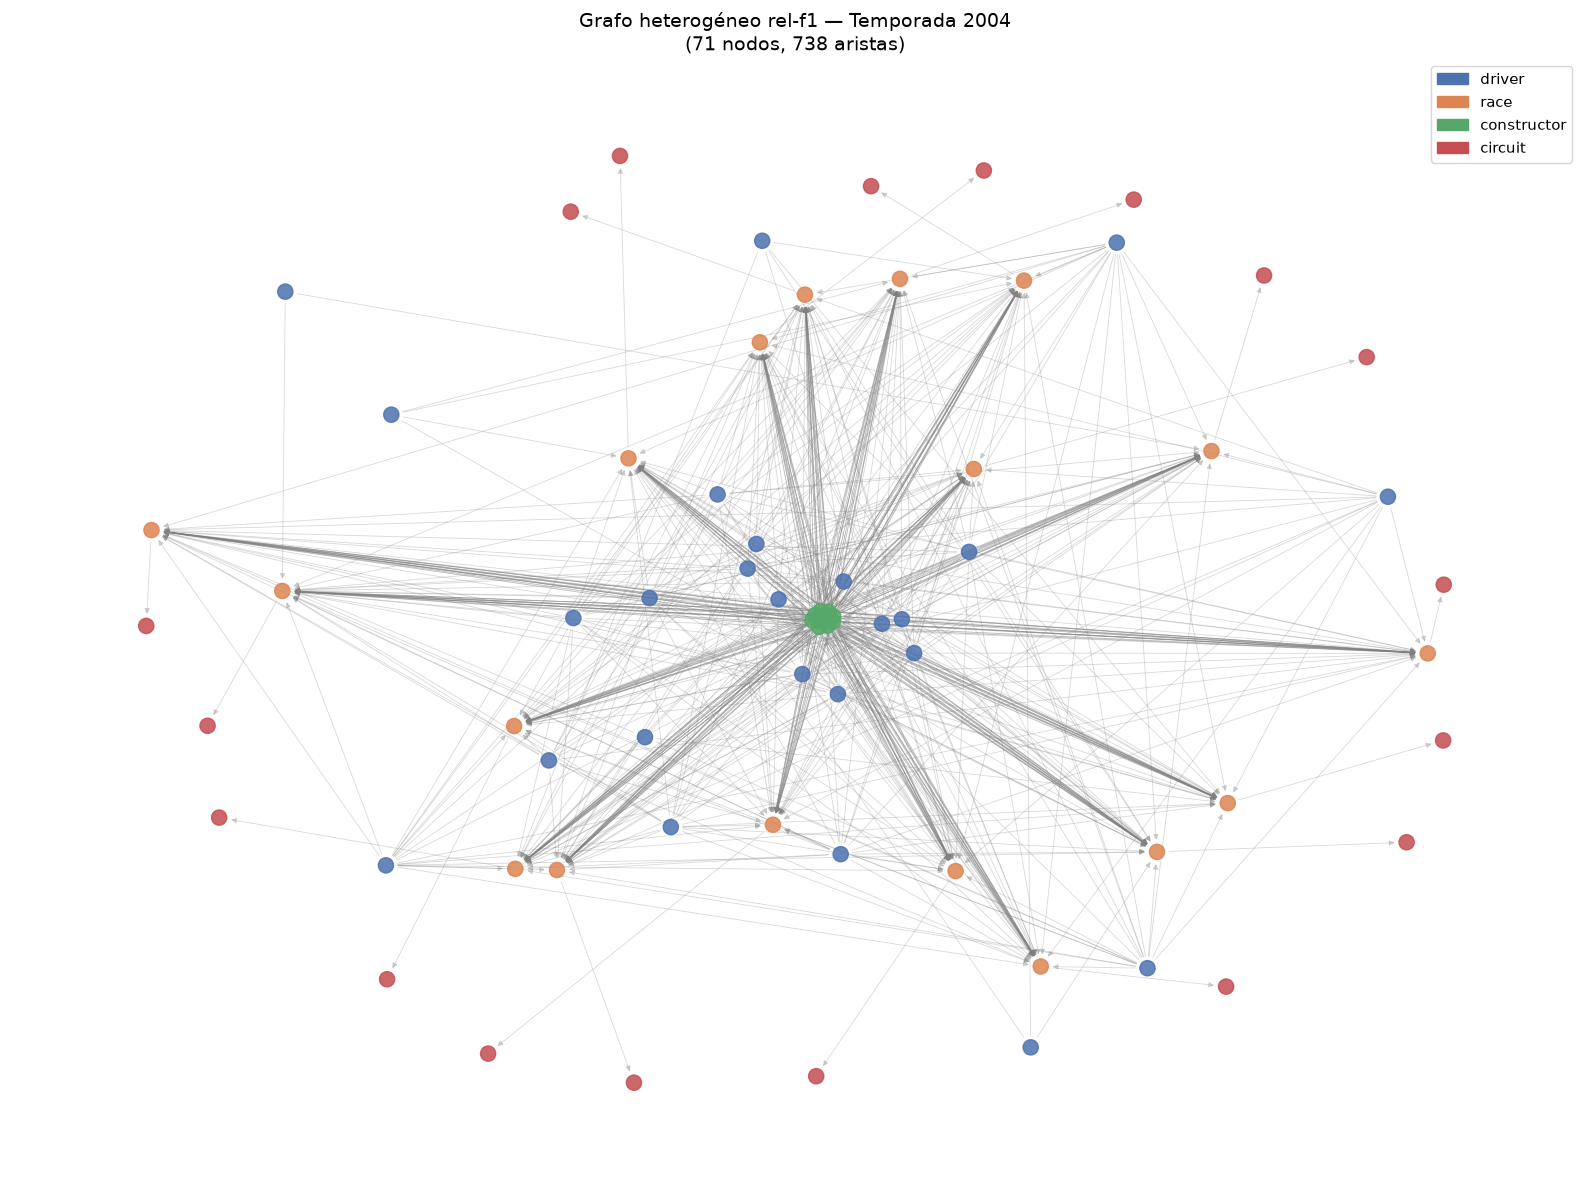

In [116]:
# ── 6.1 Spring layout con colores por tipo de nodo ─────────────────────────
node_colors = [NODE_COLORS[G.nodes[n]['ntype']] for n in G.nodes]

fig, ax = plt.subplots(figsize=(16, 12))
pos = nx.spring_layout(G, k=3 / np.sqrt(G.number_of_nodes()), seed=42)

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=120, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.3, arrows=True,
                       arrowsize=8, width=0.6, ax=ax)

ax.set_title(f'Grafo heterogéneo rel-f1 — Temporada {SEASON}\n'
             f'({G.number_of_nodes()} nodos, {G.number_of_edges()} aristas)',
             fontsize=14)
ax.axis('off')

legend_handles = [mpatches.Patch(color=c, label=t) for t, c in NODE_COLORS.items()]
ax.legend(handles=legend_handles, fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

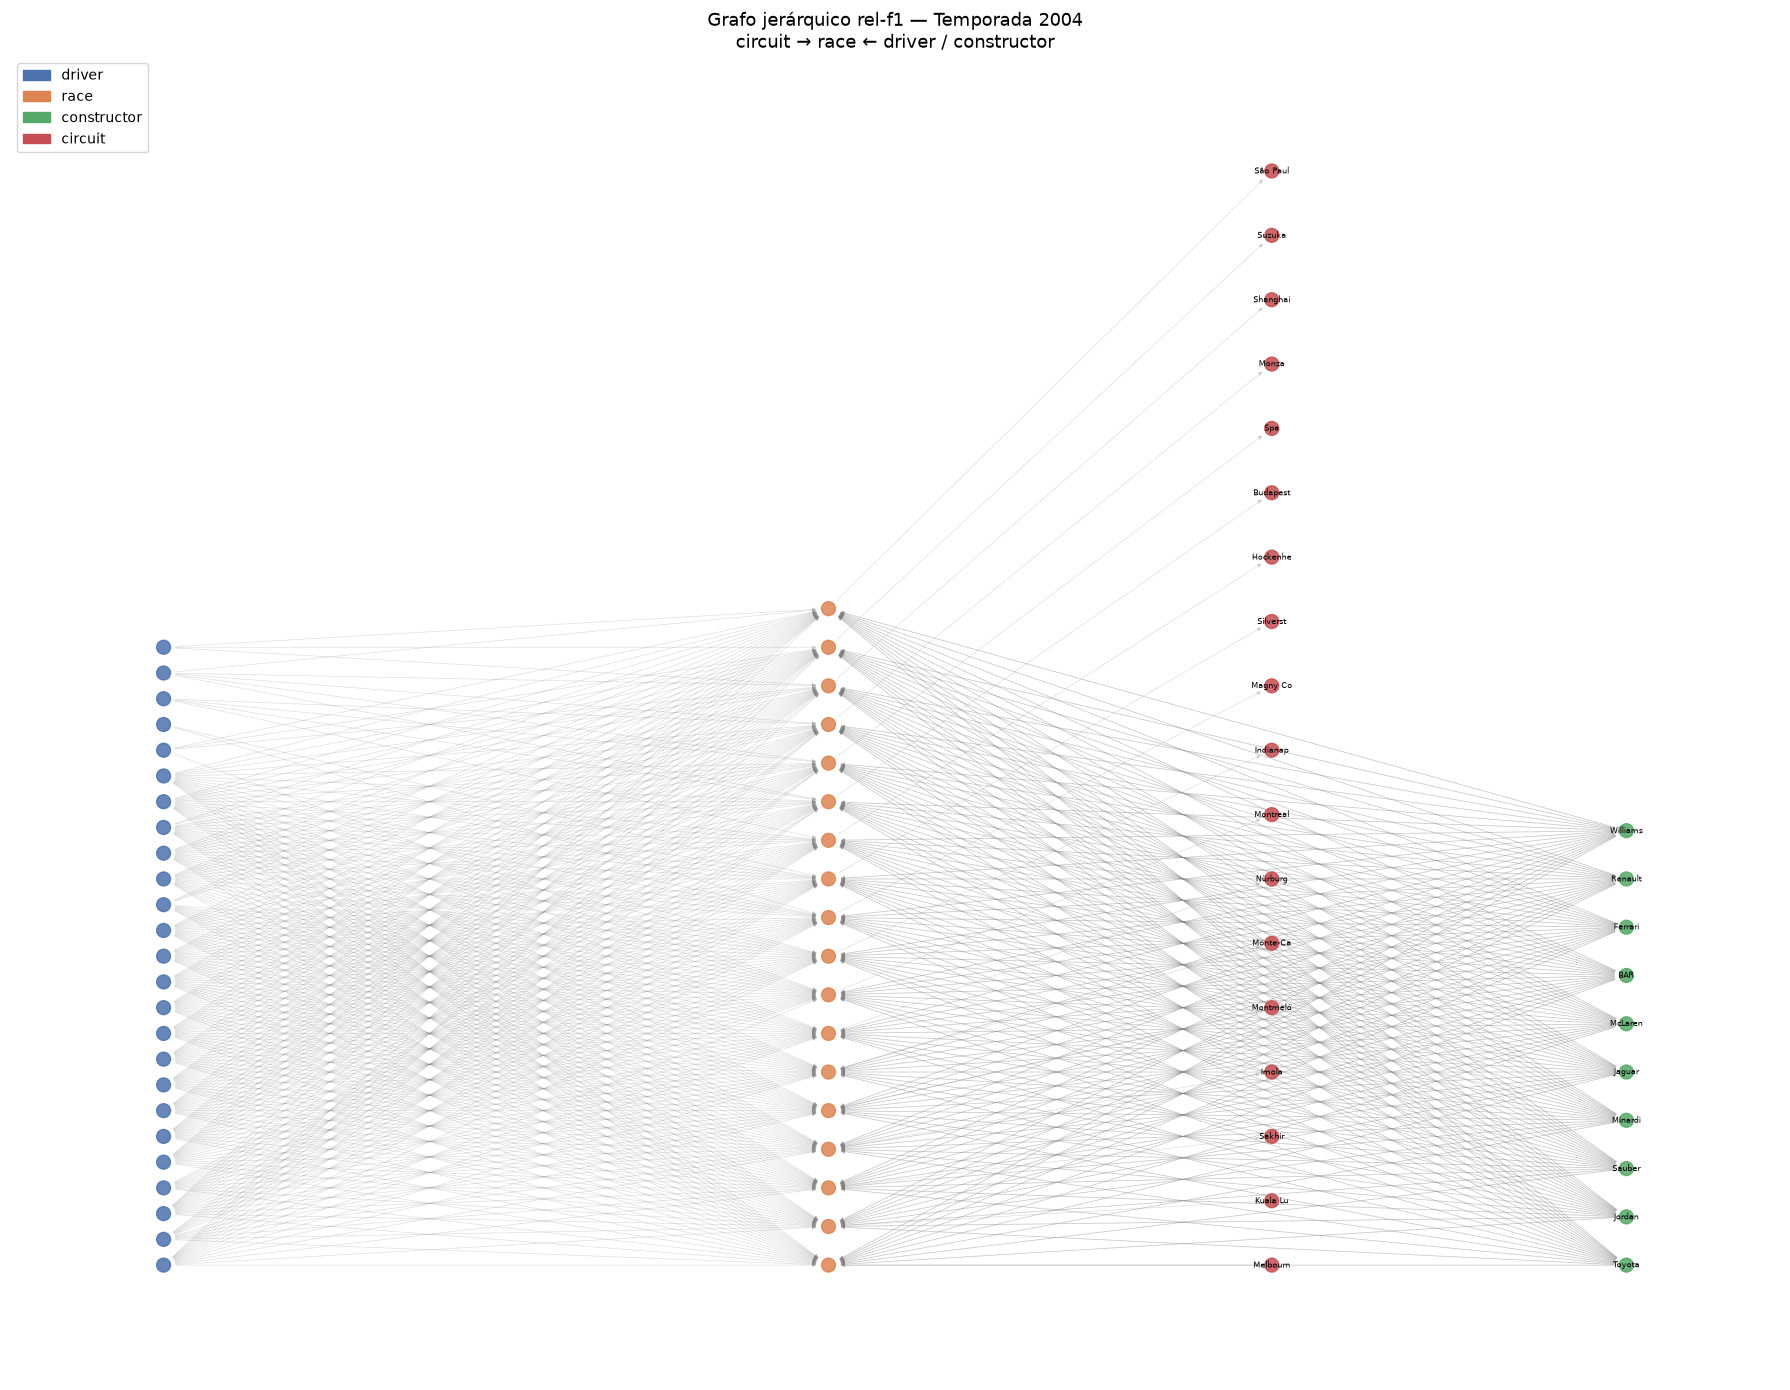

In [117]:
# ── 6.2 Vista jerárquica por tipo de nodo ──────────────────────────────────
# Posición manual: circuit → race → driver/constructor (izq/der)

circuit_nodes     = [n for n, d in G.nodes(data=True) if d['ntype'] == 'circuit']
race_nodes        = [n for n, d in G.nodes(data=True) if d['ntype'] == 'race']
driver_nodes      = [n for n, d in G.nodes(data=True) if d['ntype'] == 'driver']
constructor_nodes = [n for n, d in G.nodes(data=True) if d['ntype'] == 'constructor']

pos_hier = {}
for i, n in enumerate(circuit_nodes):
    pos_hier[n] = (3, i * 2)
for i, n in enumerate(race_nodes):
    pos_hier[n] = (2, i * 1.2)
for i, n in enumerate(driver_nodes):
    pos_hier[n] = (0.5, i * 0.8)
for i, n in enumerate(constructor_nodes):
    pos_hier[n] = (3.8, i * 1.5)

fig, ax = plt.subplots(figsize=(18, 14))
nx.draw_networkx_nodes(G, pos_hier, node_color=node_colors, node_size=100, alpha=0.85, ax=ax)
nx.draw_networkx_edges(G, pos_hier, edge_color='gray', alpha=0.25, arrows=True,
                       arrowsize=6, width=0.5, ax=ax)

# Etiquetas solo en circuitos y equipos (menos densos)
labels_show = {n: G.nodes[n]['label'] for n in circuit_nodes + constructor_nodes}
nx.draw_networkx_labels(G, pos_hier, labels=labels_show, font_size=6, ax=ax)

ax.set_title(f'Grafo jerárquico rel-f1 — Temporada {SEASON}\n'
             f'circuit → race ← driver / constructor', fontsize=13)
ax.axis('off')
ax.legend(handles=legend_handles, fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

---
## 7 · Análisis estructural del grafo

Calculamos métricas a nivel de **nodo**, **arista** y **grafo** siguiendo el esquema del Lab 8.

In [118]:
# ── 7.1 Métricas globales del grafo completo ───────────────────────────────
n_drivers      = len(df_drivers)
n_races        = len(df_races)
n_constructors = len(df_constructors)
n_circuits     = len(df_circuits)
n_results      = len(df_results)
n_qual         = len(df_qualifying)
n_nodes_total  = n_drivers + n_races + n_constructors + n_circuits
n_edges_total  = n_results * 2 + n_races + n_qual  # competes_in + fields_in + held_at + qualifies_in

density_global = n_edges_total / (n_nodes_total * (n_nodes_total - 1))

print('━' * 55)
print(f'  Nodos totales          : {n_nodes_total:>8,}')
print(f'    └─ Pilotos           : {n_drivers:>8,}')
print(f'    └─ Carreras          : {n_races:>8,}')
print(f'    └─ Constructores     : {n_constructors:>8,}')
print(f'    └─ Circuitos         : {n_circuits:>8,}')
print(f'  Aristas totales (aprox): {n_edges_total:>8,}')
print(f'  Densidad global        : {density_global:.6f}')
print('━' * 55)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Nodos totales          :    1,965
    └─ Pilotos           :      857
    └─ Carreras          :      820
    └─ Constructores     :      211
    └─ Circuitos         :       77
  Aristas totales (aprox):   45,366
  Densidad global        : 0.011755
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


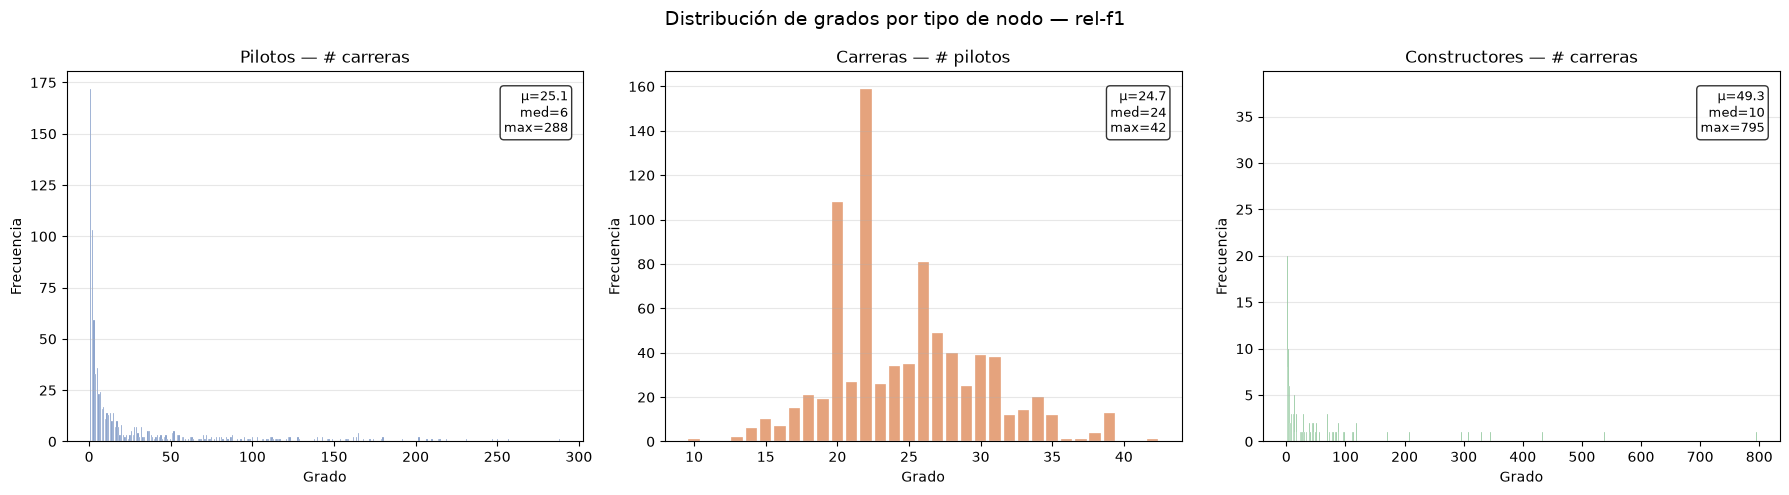

In [119]:
# ── 7.2 Distribución de grados por tipo de nodo ────────────────────────────

# Grado de pilotos: número de carreras en las que participaron
deg_driver  = df_results.groupby('driverId')['raceId'].nunique()
# Grado de carreras: número de pilotos que participaron
deg_race    = df_results.groupby('raceId')['driverId'].nunique()
# Grado de constructores: número de carreras en las que participaron
deg_constr  = df_results.groupby('constructorId')['raceId'].nunique()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pairs = [
    (deg_driver, 'Pilotos — # carreras', '#4C72B0'),
    (deg_race,   'Carreras — # pilotos', '#DD8452'),
    (deg_constr, 'Constructores — # carreras', '#55A868'),
]

for ax, (deg, label, color) in zip(axes, pairs):
    counts = Counter(deg.values)
    x = sorted(counts.keys())
    y = [counts[k] for k in x]
    ax.bar(x, y, color=color, alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Grado')
    ax.set_ylabel('Frecuencia')
    ax.set_title(label)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.97, 0.95, f'μ={deg.mean():.1f}\nmed={deg.median():.0f}\nmax={deg.max()}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Distribución de grados por tipo de nodo — rel-f1', fontsize=14)
plt.tight_layout()
plt.show()

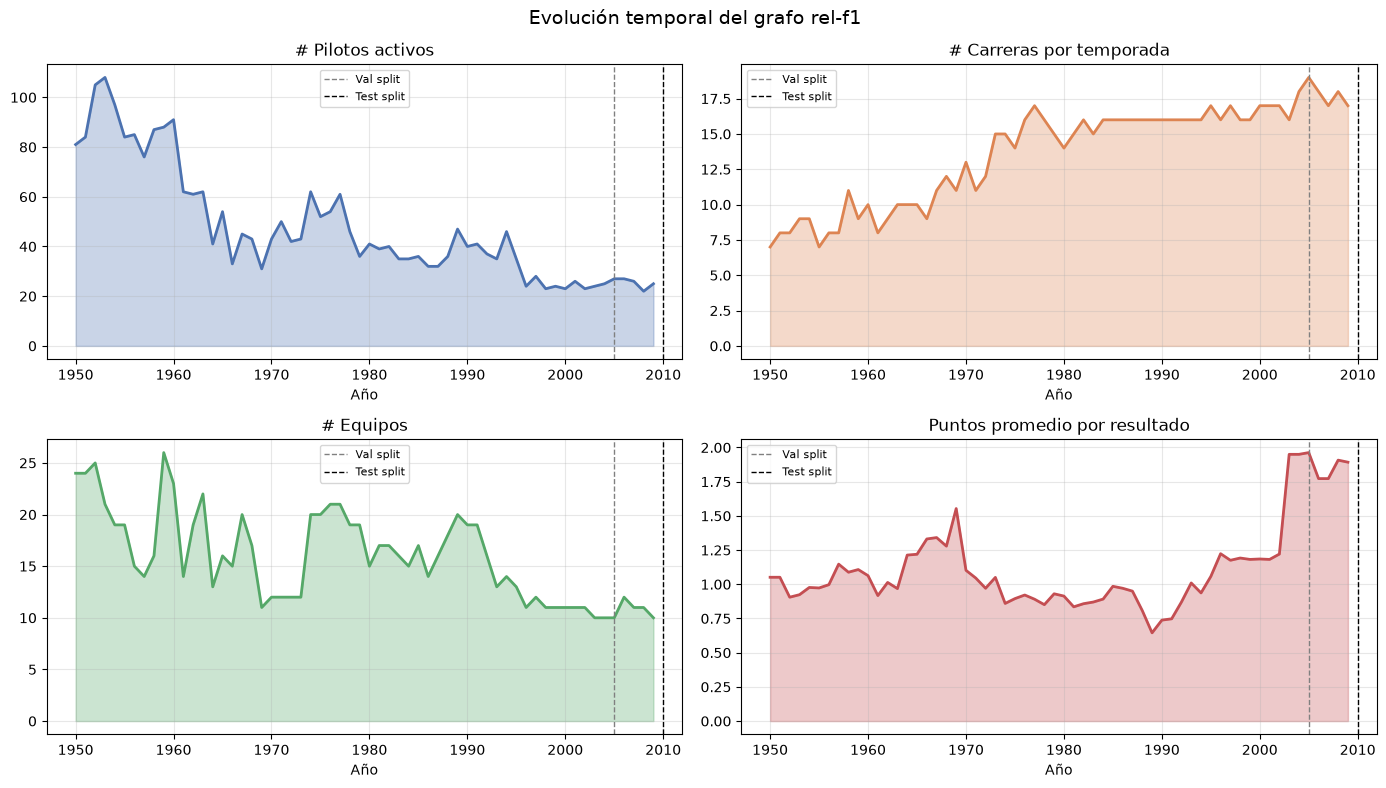

In [120]:
# ── 7.3 Evolución temporal del grafo ───────────────────────────────────────
df_results_t = df_results.merge(df_races[['raceId', 'year']], on='raceId')

stats_year = df_results_t.groupby('year').agg(
    n_pilotos=('driverId', 'nunique'),
    n_carreras=('raceId', 'nunique'),
    n_equipos=('constructorId', 'nunique'),
    puntos_avg=('points', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
labels_plot = ['# Pilotos activos', '# Carreras por temporada',
               '# Equipos', 'Puntos promedio por resultado']
cols   = ['n_pilotos', 'n_carreras', 'n_equipos', 'puntos_avg']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, lbl, color in zip(axes.flat, cols, labels_plot, colors):
    ax.fill_between(stats_year['year'], stats_year[col], alpha=0.3, color=color)
    ax.plot(stats_year['year'], stats_year[col], color=color, linewidth=2)
    ax.axvline(2005, color='gray', linestyle='--', linewidth=1, label='Val split')
    ax.axvline(2010, color='black', linestyle='--', linewidth=1, label='Test split')
    ax.set_title(lbl)
    ax.set_xlabel('Año')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Evolución temporal del grafo rel-f1', fontsize=14)
plt.tight_layout()
plt.show()

MAD global  = 1.0062
MAD vecinos = 1.0258
MAD remotos = 1.0019
MADGap      = -0.0239  ← baseline aleatorio, esperado ≈ 0

Tras el entrenamiento del GNN, esperamos MADGap > 0
(vecinos más similares entre sí que nodos remotos)


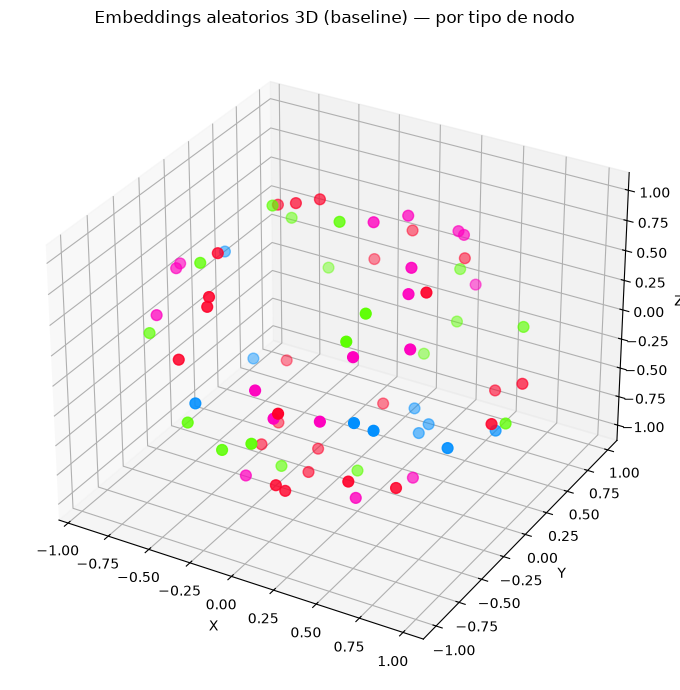

In [121]:
# ── 7.4 MAD baseline (embeddings aleatorios) — Lab 8 ──────────────────────
# Calculamos MAD sobre el subgrafo de la temporada para tener un baseline
# antes de entrenar el GNN. MADGap ≈ 0 con embeddings aleatorios es lo esperado.

np.random.seed(42)
nodes_list = list(G.nodes)
n_sub = len(nodes_list)
dim   = 3

Z_rand = np.random.randn(n_sub, dim)
Z_rand = Z_rand / np.linalg.norm(Z_rand, axis=1, keepdims=True)

G_undir = G.to_undirected()
A = nx.to_numpy_array(G_undir, nodelist=nodes_list)

mad_global = compute_mad(Z_rand)
mad_nbrs   = compute_mad(Z_rand, mask=A)
mad_remote = compute_mad(Z_rand, mask=1.0 - A)
mad_gap    = mad_remote - mad_nbrs

print(f'MAD global  = {mad_global:.4f}')
print(f'MAD vecinos = {mad_nbrs:.4f}')
print(f'MAD remotos = {mad_remote:.4f}')
print(f'MADGap      = {mad_gap:.4f}  ← baseline aleatorio, esperado ≈ 0')
print(f'\nTras el entrenamiento del GNN, esperamos MADGap > 0')
print(f'(vecinos más similares entre sí que nodos remotos)')

# Scatter 3D por tipo de nodo
type_color_map = {'driver': 0, 'race': 1, 'constructor': 2, 'circuit': 3}
colors_3d = np.array([type_color_map[G.nodes[n]['ntype']] for n in nodes_list])
plot_embeddings_3d(Z_rand, title='Embeddings aleatorios 3D (baseline) — por tipo de nodo', colors=colors_3d)

In [122]:
# ── 7.5 Tabla resumen de métricas estructurales ────────────────────────────
metrics = {
    'Métrica': [
        'Nodos totales', 'Aristas totales (aprox)',
        'Densidad global', 'Grado medio pilotos (# carreras)',
        'Grado medio carreras (# pilotos)', 'Grado medio constructores',
        'Máx carreras por piloto', 'Máx pilotos por carrera'
    ],
    'Valor': [
        f'{n_nodes_total:,}', f'{n_edges_total:,}',
        f'{density_global:.6f}', f'{deg_driver.mean():.1f}',
        f'{deg_race.mean():.1f}', f'{deg_constr.mean():.1f}',
        f'{deg_driver.max()}', f'{deg_race.max()}'
    ]
}
pd.DataFrame(metrics).style.set_caption('Análisis estructural — rel-f1').hide(axis='index')

Métrica,Valor
Nodos totales,"1,965"
Aristas totales (aprox),"45,366"
Densidad global,0.011755
Grado medio pilotos (# carreras),25.1
Grado medio carreras (# pilotos),24.7
Grado medio constructores,49.3
Máx carreras por piloto,288
Máx pilotos por carrera,42


---
## 8 · HeteroData para PyTorch Geometric

Construimos el grafo heterogéneo en formato `HeteroData` de PyG,
listo para alimentar el modelo GNN (IDGNN baseline y GAT como mejora).

> Este mismo grafo heterogéneo servirá como entrada al modelo de la sección 9: los embeddings de `driver` y `circuit` aprendidos vía message passing se combinan (producto punto) para puntuar enlaces candidatos en la tarea `driver-circuit-compete`. No se añade una arista directa driver→circuit como input (eso filtraría el objetivo); el enlace se predice, no se observa.


In [123]:
from torch_geometric.data import HeteroData

# Re-indexar IDs a enteros 0-based
driver_idx  = {did: i for i, did in enumerate(df_drivers['driverId'])}
race_idx    = {rid: i for i, rid in enumerate(df_races['raceId'])}
constr_idx  = {cid: i for i, cid in enumerate(df_constructors['constructorId'])}
circuit_idx = {cid: i for i, cid in enumerate(df_circuits['circuitId'])}

data = HeteroData()

# ── Features de nodos (identidad como placeholder — serán aprendidas) ───────
data['driver'].num_nodes      = len(driver_idx)
data['race'].num_nodes        = len(race_idx)
data['constructor'].num_nodes = len(constr_idx)
data['circuit'].num_nodes     = len(circuit_idx)

# Features numéricas disponibles
data['circuit'].x = torch.tensor(
    df_circuits[['lat', 'lng', 'alt']].fillna(0).values, dtype=torch.float
)

# ── Aristas driver → race (competes_in) — de results ───────────────────────
src_dr = torch.tensor([driver_idx[d] for d in df_results['driverId']], dtype=torch.long)
dst_dr = torch.tensor([race_idx[r]   for r in df_results['raceId']],   dtype=torch.long)
data['driver', 'competes_in', 'race'].edge_index = torch.stack([src_dr, dst_dr])
data['driver', 'competes_in', 'race'].edge_attr  = torch.tensor(
    df_results[['position_norm', 'points_norm']].values, dtype=torch.float
)

# ── Aristas constructor → race (fields_in) — de constructor_results ─────────
df_cres_valid = df_cres[df_cres['constructorId'].isin(constr_idx) & df_cres['raceId'].isin(race_idx)]
src_cr = torch.tensor([constr_idx[c] for c in df_cres_valid['constructorId']], dtype=torch.long)
dst_cr = torch.tensor([race_idx[r]   for r in df_cres_valid['raceId']],        dtype=torch.long)
data['constructor', 'fields_in', 'race'].edge_index = torch.stack([src_cr, dst_cr])

# ── Aristas race → circuit (held_at) — de races ─────────────────────────────
src_rc = torch.tensor([race_idx[r]    for r in df_races['raceId']],    dtype=torch.long)
dst_rc = torch.tensor([circuit_idx[c] for c in df_races['circuitId']], dtype=torch.long)
data['race', 'held_at', 'circuit'].edge_index = torch.stack([src_rc, dst_rc])

# ── Aristas driver → race (qualifies_in) — de qualifying ────────────────────
df_q_valid = df_qualifying[df_qualifying['driverId'].isin(driver_idx) & df_qualifying['raceId'].isin(race_idx)]
src_q = torch.tensor([driver_idx[d] for d in df_q_valid['driverId']], dtype=torch.long)
dst_q = torch.tensor([race_idx[r]   for r in df_q_valid['raceId']],   dtype=torch.long)
data['driver', 'qualifies_in', 'race'].edge_index = torch.stack([src_q, dst_q])
data['driver', 'qualifies_in', 'race'].edge_attr  = torch.tensor(
    df_q_valid[['position']].values, dtype=torch.float
)

# ── Aristas inversas para propagación bidireccional ─────────────────────────
data['race', 'rev_competes_in', 'driver'].edge_index  = torch.stack([dst_dr, src_dr])
data['race', 'rev_fields_in', 'constructor'].edge_index = torch.stack([dst_cr, src_cr])
data['circuit', 'rev_held_at', 'race'].edge_index     = torch.stack([dst_rc, src_rc])

print(data)
print(f'\nTipos de nodos  : {data.node_types}')
print(f'Tipos de aristas: {data.edge_types}')

HeteroData(
  driver={ num_nodes=857 },
  race={ num_nodes=820 },
  constructor={ num_nodes=211 },
  circuit={
    num_nodes=77,
    x=[77, 3],
  },
  (driver, competes_in, race)={
    edge_index=[2, 20232],
    edge_attr=[20232, 2],
  },
  (constructor, fields_in, race)={ edge_index=[2, 9408] },
  (race, held_at, circuit)={ edge_index=[2, 820] },
  (driver, qualifies_in, race)={
    edge_index=[2, 4082],
    edge_attr=[4082, 1],
  },
  (race, rev_competes_in, driver)={ edge_index=[2, 20232] },
  (race, rev_fields_in, constructor)={ edge_index=[2, 9408] },
  (circuit, rev_held_at, race)={ edge_index=[2, 820] }
)

Tipos de nodos  : ['driver', 'race', 'constructor', 'circuit']
Tipos de aristas: [('driver', 'competes_in', 'race'), ('constructor', 'fields_in', 'race'), ('race', 'held_at', 'circuit'), ('driver', 'qualifies_in', 'race'), ('race', 'rev_competes_in', 'driver'), ('race', 'rev_fields_in', 'constructor'), ('circuit', 'rev_held_at', 'race')]


---
## 9 · Tarea objetivo: `driver-circuit-compete`

**Predicción:** dado el historial de un piloto hasta la fecha `t`, ¿en qué circuitos competirá durante los próximos 365 días?  
**Tipo:** *link prediction* (recomendación driver → circuit), no clasificación ni regresión  
**Nivel de análisis:** nivel arista/enlace — la predicción **es** el enlace `(driver, circuit)`, no un atributo de un nodo  
**Entidad origen:** `driver` (857 nodos) · **Entidad destino:** `circuit` (catálogo de 77 nodos candidatos)  
**Métricas:** Precision@10, Recall@10, MAP@10 (RelBench usa `eval_k = 10`)  
**Split temporal:** train < 2005 | val 2005-2009 | test 2010+ (igual que antes; cambia el `timedelta` de la ventana objetivo a 1 año)

> Nota: esta tarea reemplaza a `driver-top3`. A diferencia de esa tarea (clasificación binaria a nivel nodo con señal de arista), aquí el objetivo mismo es la existencia del enlace driver–circuito — confirma exactamente la intuición de "predecir si existe un enlace" planteada antes.


In [124]:
task = get_task('rel-f1', 'driver-circuit-compete', download=True)

train_table = task.get_table('train')
val_table   = task.get_table('val')
test_table  = task.get_table('test')

print('Tarea: driver-circuit-compete (link prediction)')
print(f'  Train: {len(train_table.df):,} filas')
print(f'  Val  : {len(val_table.df):,} filas')
print(f'  Test : {len(test_table.df):,} filas')
print(f'  Columnas        : {list(train_table.df.columns)}')
print(f'  Entidad origen  : {task.src_entity_table} ({task.src_entity_col})')
print(f'  Entidad destino : {task.dst_entity_table} ({task.dst_entity_col})')
print(f'  Métricas        : {[m.__name__ for m in task.metrics]}')
print(f'  eval_k          : {task.eval_k}')

print('\nMuestra train (cada fila = un piloto en una fecha de corte,'
      ' con la lista de circuitos donde competirá en el próximo año):')
display(train_table.df.head(5))


Tarea: driver-circuit-compete (link prediction)
  Train: 2,649 filas
  Val  : 27 filas
  Test : 27 filas
  Columnas        : ['date', 'driverId', 'circuitId']
  Entidad origen  : drivers (driverId)
  Entidad destino : circuits (circuitId)
  Métricas        : ['link_prediction_precision', 'link_prediction_recall', 'link_prediction_map']
  eval_k          : 10

Muestra train (cada fila = un piloto en una fecha de corte, con la lista de circuitos donde competirá en el próximo año):


,date,driverId,circuitId
0,1951-01-15,529,[18]
1,1960-01-13,434,"[12, 13, 54]"
2,1961-01-12,477,"[12, 5]"
3,1961-01-12,436,"[19, 38, 54, 12, 57]"
4,1963-01-12,346,"[54, 31, 55, 45, 8, 19, 13, 12, 38, 5]"


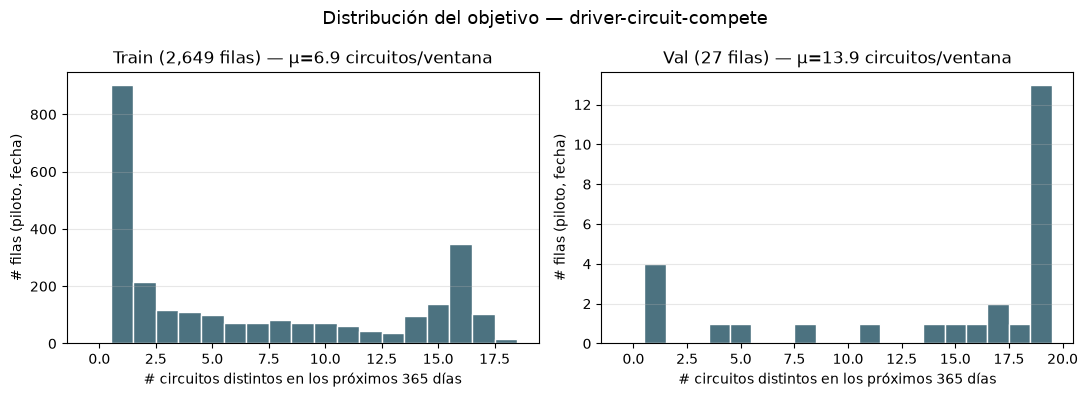

Test: 27 filas (objetivo oculto por RelBench para evaluación)
Catálogo de circuitos candidatos: 77

Baseline "top-10 circuitos más frecuentes":
  Precision@10 promedio en train ≈ 0.323
  (referencia simple — el modelo GNN debe superar claramente este baseline)


In [125]:
# Distribución del objetivo: tamaño de la lista de circuitos por piloto/ventana
# Nota: la tabla de test NO incluye la columna objetivo (circuitId) — se oculta
# para evaluación, así que el análisis de distribución solo es posible en train/val.
# Nota técnica: DuckDB devuelve la columna LIST(...) como numpy.ndarray, no como
# list de Python -- por eso usamos una función robusta a ambos tipos.
n_circuits_total = len(df_circuits)

def safe_len(x):
    if x is None:
        return 0
    try:
        return len(x)
    except TypeError:
        return 0

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (split_df, label) in zip(axes, [
    (train_table.df, 'Train'),
    (val_table.df,   'Val'),
]):
    list_lens = split_df['circuitId'].apply(safe_len)
    ax.hist(list_lens, bins=range(0, int(list_lens.max())+2), color='#4C7280', edgecolor='white', align='left')
    ax.set_title(f'{label} ({len(split_df):,} filas) — μ={list_lens.mean():.1f} circuitos/ventana')
    ax.set_xlabel('# circuitos distintos en los próximos 365 días')
    ax.set_ylabel('# filas (piloto, fecha)')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribución del objetivo — driver-circuit-compete', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Test: {len(test_table.df):,} filas (objetivo oculto por RelBench para evaluación)')
print(f'Catálogo de circuitos candidatos: {n_circuits_total}')

# Baseline de popularidad: ¿qué tan fuerte es recomendar siempre los circuitos
# más frecuentes del historial? (referencia para comparar contra el GNN)
top_circuits_hist = df_races['circuitId'].value_counts().head(task.eval_k).index.tolist()

def precision_at_k(true_list, pred_list, k):
    if safe_len(true_list) == 0:
        return None
    pred_k = pred_list[:k]
    hits = len(set(pred_k) & set(true_list))
    return hits / k

train_precisions = train_table.df['circuitId'].apply(
    lambda y: precision_at_k(y, top_circuits_hist, task.eval_k)
).dropna()

print(f'\nBaseline "top-{task.eval_k} circuitos más frecuentes":')
print(f'  Precision@{task.eval_k} promedio en train ≈ {train_precisions.mean():.3f}')
print('  (referencia simple — el modelo GNN debe superar claramente este baseline)')


---
## 10 · Resumen

| Característica | Valor |
|---|---|
| Dataset | rel-f1 (RelBench, Stanford SNAP) |
| Dominio | Fórmula 1 — recomendación de circuitos por piloto |
| Tipo de grafo | Heterogéneo dirigido (4 tipos de nodo, 5 tipos de arista) |
| Nodos totales | 1,965 (857 pilotos + 820 carreras + 211 equipos + 77 circuitos) |
| Aristas principales | ~40,700 (results + qualifying + races) |
| Tarea objetivo | `driver-circuit-compete` — link prediction (driver → circuit) |
| Nivel de análisis | Nivel arista/enlace — el objetivo es la existencia del enlace |
| Split temporal | Train < 2005 \| Val 2005-2009 \| Test 2010+ (ventana objetivo = 1 año) |
| Métricas | Precision@10, Recall@10, MAP@10 |

### Próximos pasos (Entregable 3)

1. **`02_baseline_idgnn.ipynb`** — encoder heterogéneo (IDGNN/HeteroGNN de RelBench) para `driver` y `circuit`, decoder de producto punto + *negative sampling*, entrenado como baseline de link prediction.
2. **`03_mejora_gat.ipynb`** — reemplazar las capas `SAGEConv` del encoder por `GATv2Conv` (Lab 10) y comparar Precision@10 / Recall@10 / MAP@10 contra el baseline.
3. Análisis de discrepancias con los resultados del paper de RelBench (tabla de leaderboard, métrica MAP).
4. Baseline de popularidad (sección 9) como referencia mínima a superar.
